# Графическое решение (Вариант 7)

**Целевая функция:**

$$
\min\; f(x_1,x_2)= -5x_1-2x_2+x_1^2-x_1x_2+x_2^2
$$

**Ограничения:**
- $15-2x_1-3x_2\ge 0$
- $x_1+2x_2-8=0$
- $x_1\ge 0$, $x_2\ge 0$

Ниже: строим допустимое множество и линии уровня, а также отмечаем **минимум** и **максимум** на допустимом множестве.

In [25]:
import numpy as np
import matplotlib.pyplot as plt


def f(x1, x2):
    return -5 * x1 - 2 * x2 + x1**2 - x1 * x2 + x2**2


# Ограничения

def g1(x1, x2):
    return 15 - 2 * x1 - 3 * x2


def h2(x1, x2):
    return x1 + 2 * x2 - 8


def g3(x1, x2):
    return x1


def g4(x1, x2):
    return x2


# Отрезок на h2=0
x2_min, x2_max = 1.0, 4.0
x2_seg = np.linspace(x2_min, x2_max, 2001)
x1_seg = 8 - 2 * x2_seg

f_seg = f(x1_seg, x2_seg)
i_min = int(np.argmin(f_seg))
i_max = int(np.argmax(f_seg))

xmin = (float(x1_seg[i_min]), float(x2_seg[i_min]))
xmax = (float(x1_seg[i_max]), float(x2_seg[i_max]))

print(f"Отрезок: x2 ∈ [{x2_min:g}, {x2_max:g}], x1 = 8 - 2x2")
print(f"MIN: x = ({xmin[0]:.4f}, {xmin[1]:.4f}), f = {f(xmin[0], xmin[1]):.4f}")
print(f"MAX: x = ({xmax[0]:.4f}, {xmax[1]:.4f}), f = {f(xmax[0], xmax[1]):.4f}")


Отрезок: x2 ∈ [1, 4], x1 = 8 - 2x2
MIN: x = (3.4290, 2.2855), f = -12.5714
MAX: x = (0.0000, 4.0000), f = 8.0000


### График 2D

Сейчас построим 2D график: линии уровня функции, ограничения и допустимый отрезок. На графике отметим MIN и MAX.


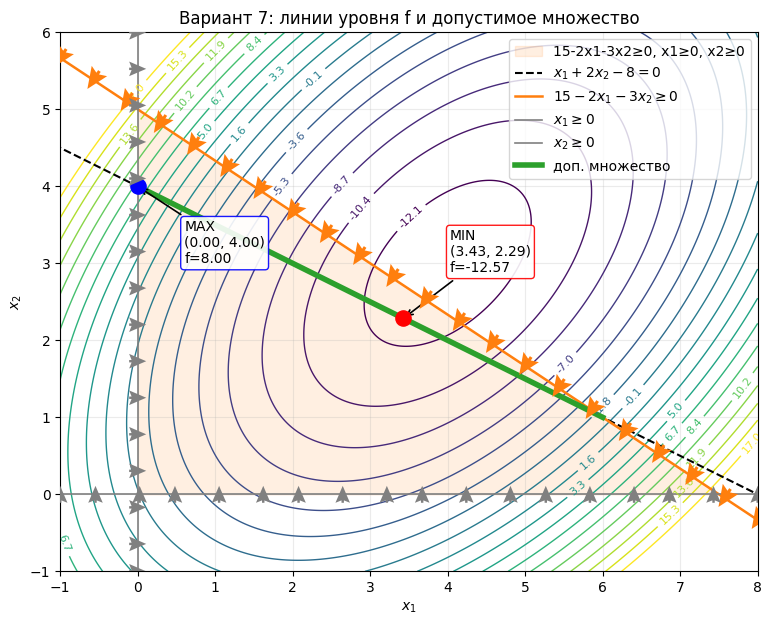

In [26]:
# 2D: уровни f + ограничения + допустимый отрезок

x1 = np.linspace(-1, 8, 600)
x2 = np.linspace(-1, 6, 600)
X1, X2 = np.meshgrid(x1, x2)
F = f(X1, X2)

fig, ax = plt.subplots(figsize=(9, 7))

levels = np.linspace(np.percentile(F, 5), np.percentile(F, 95), 18)
cs = ax.contour(X1, X2, F, levels=levels, linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Область неравенств: x1>=0, x2>=0, 15-2x1-3x2>=0
x1_fill = np.linspace(0, 8, 600)
x2_g1 = (15 - 2 * x1_fill) / 3
x2_g1_clip = np.clip(x2_g1, 0, 6)
ax.fill_between(
    x1_fill,
    0,
    x2_g1_clip,
    where=x2_g1 > 0,
    color="tab:orange",
    alpha=0.12,
    label="15-2x1-3x2≥0, x1≥0, x2≥0",
    zorder=0,
)

# Границы
x2_line = np.linspace(-1, 6, 400)
ax.plot(8 - 2 * x2_line, x2_line, "k--", lw=1.5, label=r"$x_1+2x_2-8=0$")

x1_line = np.linspace(-1, 8, 400)
ax.plot(
    x1_line,
    (15 - 2 * x1_line) / 3,
    color="tab:orange",
    lw=1.8,
    label=r"$15-2x_1-3x_2\geq 0$",
)

ax.axvline(0, color="gray", lw=1.2, label=r"$x_1\geq 0$")
ax.axhline(0, color="gray", lw=1.2, label=r"$x_2\geq 0$")


def add_boundary_arrows(
    ax,
    xs,
    ys,
    dx,
    dy,
    *,
    n=18,
    length=0.25,
    color="red",
    width=0.004,
    zorder=6,
):
    """Стрелочки вдоль границы."""
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    if xs.size < 2:
        return

    idx = np.linspace(0, xs.size - 1, n).astype(int)
    xq = xs[idx]
    yq = ys[idx]

    norm = float((dx * dx + dy * dy) ** 0.5)
    if norm == 0:
        return
    ux, uy = dx / norm, dy / norm

    U = np.full_like(xq, ux * length, dtype=float)
    V = np.full_like(yq, uy * length, dtype=float)

    ax.quiver(
        xq,
        yq,
        U,
        V,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
        color=color,
        zorder=zorder,
        pivot="mid",
        headwidth=6,
        headlength=7,
        headaxislength=6,
    )


# Стрелки в сторону допустимой области
# g1>=0 <=> 2x1+3x2<=15, поэтому внутрь примерно (-2, -3)
y_g1 = (15 - 2 * x1_line) / 3
mask = (y_g1 >= -1) & (y_g1 <= 6)
add_boundary_arrows(ax, x1_line[mask], y_g1[mask], dx=-2, dy=-3, n=22, length=0.28, color="tab:orange", width=0.0045)

_yv = np.linspace(-1, 6, 60)
_xv = np.zeros_like(_yv)
add_boundary_arrows(ax, _xv, _yv, dx=1, dy=0, n=16, length=0.22, color="gray", width=0.004)

_xh = np.linspace(-1, 8, 80)
_yh = np.zeros_like(_xh)
add_boundary_arrows(ax, _xh, _yh, dx=0, dy=1, n=18, length=0.22, color="gray", width=0.004)

# Допустимый отрезок
ax.plot(x1_seg, x2_seg, color="tab:green", lw=4, label=r"доп. множество")

# MIN / MAX
ax.scatter([xmin[0]], [xmin[1]], s=120, color="red", zorder=5)
ax.scatter([xmax[0]], [xmax[1]], s=120, color="blue", zorder=5)

ax.annotate(
    f"MIN\n({xmin[0]:.2f}, {xmin[1]:.2f})\nf={f(xmin[0], xmin[1]):.2f}",
    xy=xmin,
    xytext=(xmin[0] + 0.6, xmin[1] + 0.6),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", alpha=0.9),
)
ax.annotate(
    f"MAX\n({xmax[0]:.2f}, {xmax[1]:.2f})\nf={f(xmax[0], xmax[1]):.2f}",
    xy=xmax,
    xytext=(xmax[0] + 0.6, xmax[1] - 1.0),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="blue", alpha=0.9),
)

ax.set_title("Вариант 7: линии уровня f и допустимое множество")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 6)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

plt.show()


## Комбинированный метод

Дальше решаем задачу численно через штрафную функцию.

$$
P(x,r)=f(x_1,x_2)+\frac{1}{\sqrt r}(x_1+2x_2-8)^2+r\left(\frac{1}{15-2x_1-3x_2}+\frac{1}{x_1}+\frac{1}{x_2}\right).
$$

Как делаю:
- выбираю $r$ и постепенно уменьшаю его
- при фиксированном $r$ минимизирую $P(x,r)$ градиентным спуском
- шаг $\alpha$ подбираю по Армихо и по Вульфу
- точка должна оставаться внутри области, потому что в $P$ стоят барьеры


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# f, ограничения и штраф P(x,r) ---

def f(x1, x2):
    return -5 * x1 - 2 * x2 + x1**2 - x1 * x2 + x2**2


def h2(x1, x2):
    return x1 + 2 * x2 - 8


def g1(x1, x2):
    return 15 - 2 * x1 - 3 * x2


def P(x1, x2, r):
    # P определена только при x1>0, x2>0, g1>0 (барьеры)
    return f(x1, x2) + (1 / np.sqrt(r)) * (h2(x1, x2) ** 2) + r * (
        1 / g1(x1, x2) + 1 / x1 + 1 / x2
    )


def gradP(x1, x2, r):
    g = g1(x1, x2)
    h = h2(x1, x2)
    dPdx1 = (-5 + 2 * x1 - x2) + (2 / np.sqrt(r)) * h + (2 * r) / (g**2) - r / (x1**2)
    dPdx2 = (-2 - x1 + 2 * x2) + (4 / np.sqrt(r)) * h + (3 * r) / (g**2) - r / (x2**2)
    return np.array([dPdx1, dPdx2], dtype=float)


def feasible(x1, x2, eps=1e-9):
    return (x1 > eps) and (x2 > eps) and (g1(x1, x2) > eps)


# --- Поиск альфа (Вульф) ---

def line_search_wolfe(
    x,  # текущая точка (x1, x2)
    d,  # направление спуска (единичный антиградиент)
    r,  # параметр штрафа/барьера
    g,  # gradP(x,r) в точке x
    *,
    c1=1e-4,  # Армихо: насколько требуем убывание
    c2=0.99,  # Вульф: параметр кривизны, обычно близко к 1
    alpha_max=1.0,  # максимально пробуемый шаг
    rho=0.5,  # уменьшение шага при провале Армихо
    max_iter=100,  # максимум попыток
    alpha_min=1e-12,  # если alpha < alpha_min, считаем что поиск не удался
    curvature_expand=1.5,  # увеличение alpha, если Армихо ок, но кривизна нет
    alpha_init=None,  # стартовый alpha (например прошлый удачный)
):
    """Поиск шага alpha по Вульфу: Армихо + слабая кривизна."""

    P_curr = float(P(x[0], x[1], r))  # текущее P
    g_dot_d = float(np.dot(g, d))  # производная по направлению d

    # начальный alpha
    if alpha_init is None:
        alpha = float(alpha_max)
    else:
        alpha = float(alpha_init)

    for _ in range(max_iter):
        x_new = x + alpha * d
        P_new = float(P(x_new[0], x_new[1], r))

        # 1) Армихо: P_new <= P_curr + c1 * alpha * <gradP, d>
        if P_new > P_curr + c1 * alpha * g_dot_d:
            alpha *= rho
            if alpha < alpha_min:
                return None
            continue

        # 2) Кривизна (слабое условие Вульфа)
        g_new = gradP(x_new[0], x_new[1], r)
        gd_new = float(np.dot(g_new, d))
        if gd_new < c2 * g_dot_d:
            if alpha < alpha_max:
                alpha = min(alpha_max, alpha * curvature_expand)
                continue
            return alpha

        return alpha

    return alpha


# --- Градиентный спуск P(x,r) при фиксированном r ---

def gradient_descent_for_fixed_r(
    x0,  # начальная точка
    r,  # текущий параметр внешнего цикла
    *,
    max_iter=5000,  # максимум итераций градиентного спуска
    grad_tol=1e-3,  # точность по норме градиента
    alpha0=1.0,  # базовый максимальный шаг
    c1=1e-4,  # параметр Армихо
    c2=0.9,  # параметр кривизны (для Вульфа)
    beta=0.5,  # во сколько раз уменьшаем шаг в backtracking
    alpha_min=1e-8,  # минимальный шаг
    curvature_expand=1.5,  # увеличение шага в Вульфе, если кривизна не прошла
    line_search="armijo",  # "armijo" или "wolfe"
    warm_factor=1.5,  # "тёплый" старт alpha из прошлого шага
    verbose=False,
):
    """Градиентный спуск для P(x,r). d = -grad/||grad||, шаг — Армихо или Вульф."""
    x = np.array(x0, dtype=float)
    if not feasible(x[0], x[1]):
        raise ValueError(f"Начальная точка недопустима: x={x}")

    hist = {"x": [x.copy()], "f": [float(f(x[0], x[1]))], "P": [float(P(x[0], x[1], r))], "grad_norm": []}
    alpha_prev = None

    for k in range(max_iter):
        g = gradP(x[0], x[1], r)
        gn = float(np.linalg.norm(g))
        hist["grad_norm"].append(gn)

        if verbose and (k % 10 == 0):
            print(f"  iter {k:2d}: X=({x[0]:.4f}, {x[1]:.4f}), ||grad||={gn:.2e}")
        if gn < grad_tol:
            if verbose:
                print(f"  Сошлись за {k + 1} итераций")
            break

        d = -g / gn
        g_dot_d = float(np.dot(g, d))

        x_try = None
        ok = False

        if line_search == "armijo":
            # Армихо (backtracking): уменьшаем a, пока P не убывает "достаточно"
            P_curr = float(P(x[0], x[1], r))
            a = float(alpha0 if alpha_prev is None else min(alpha0, alpha_prev * warm_factor))

            for _ in range(80):
                x_try = x + a * d

                # барьер: точка должна оставаться внутри допустимой области
                if not feasible(x_try[0], x_try[1]):
                    a *= beta
                    if a < alpha_min:
                        break
                    continue

                P_try = float(P(x_try[0], x_try[1], r))

                # условие Армихо
                if P_try < P_curr + c1 * a * g_dot_d:
                    ok = True
                    break

                a *= beta
                if a < alpha_min:
                    break

        elif line_search == "wolfe":
            # Вульф: Армихо + кривизна
            a0 = None if alpha_prev is None else min(alpha0, alpha_prev * warm_factor)
            a = line_search_wolfe(
                x,
                d,
                r,
                g,
                c1=c1,
                c2=c2,
                alpha_max=alpha0,
                rho=beta,
                max_iter=100,
                alpha_min=alpha_min,
                curvature_expand=curvature_expand,
                alpha_init=a0,
            )
            if a is not None and a >= alpha_min:
                x_try = x + a * d
                ok = feasible(x_try[0], x_try[1])

        if (not ok) or (x_try is None):
            if verbose:
                print(f"  Остановка: поиск alpha не удался (итерация {k + 1})")
            break

        x = x_try
        alpha_prev = float(a)
        hist["x"].append(x.copy())
        hist["f"].append(float(f(x[0], x[1])))
        hist["P"].append(float(P(x[0], x[1], r)))

    return x, hist


# --- Комбинированный метод (внешний цикл по r) ---

def combined_method(
    x0,
    *,
    r0=10.0,
    r_factor=0.25,
    r_min=1e-8,
    theta0=1e-5,
    eps_grad=1e-3,
    line_search="armijo",
    verbose=False,
    verbose_subtitle="",
):
    r = float(r0)
    x = np.array(x0, dtype=float)

    if verbose:
        title = "Решение задачи на ЭВМ"
        if verbose_subtitle:
            title += f" — {verbose_subtitle}"
        print(title)
        print()
        xi, xj = float(x[0]), float(x[1])
        print(f"Начальная точка: ({xi:g}, {xj:g})")
        print(f"f = {f(xi, xj):g}")
        print(f"h2 = x1 + 2x2 - 8 = {h2(xi, xj):g}")
        print(f"g1 = 15 - 2x1 - 3x2 = {g1(xi, xj):g}")
        print(f"P(X, r) = {P(xi, xj, r)}")
        print()

    all_hist = {"x": [], "f": [], "P": [], "r": [], "outer": [], "steps_total": 0}
    outer_k = 0

    while r >= r_min:
        if verbose:
            print(f"r = {r}")

        x, hist_inner = gradient_descent_for_fixed_r(
            x,
            r,
            grad_tol=eps_grad,
            line_search=line_search,
            verbose=verbose,
        )

        all_hist["steps_total"] += len(hist_inner["grad_norm"])

        j0 = 0 if outer_k == 0 else 1
        for j in range(j0, len(hist_inner["x"])):
            all_hist["x"].append(hist_inner["x"][j])
            all_hist["f"].append(hist_inner["f"][j])
            all_hist["P"].append(hist_inner["P"][j])
            all_hist["r"].append(r)
            all_hist["outer"].append(outer_k)

        if verbose:
            xf, yf = float(x[0]), float(x[1])
            print(f"  X = ({xf:.6f}, {yf:.6f})")
            print(f"  f = {f(xf, yf):.6f}")
            print(f"  h2 = {h2(xf, yf):.2e}")
            print(f"  g1 = {g1(xf, yf):.2e}")
            print(f"P(X, r) = {P(xf, yf, r)}")
            print()

        if abs(all_hist["P"][-1] - all_hist["f"][-1]) <= theta0 and r < 1e-2:
            break

        r *= r_factor
        outer_k += 1

    if verbose:
        print("Итог")
        xf, yf = float(x[0]), float(x[1])
        print(f"X* = ({xf:.6f}, {yf:.6f})")
        print(f"f* = {f(xf, yf):.6f}")
        print(f"Проверка x1 + 2x2 - 8 = {h2(xf, yf):.2e}")
        print(f"Проверка 15 - 2x1 - 3x2 = {g1(xf, yf):.2e}")
        x1t, x2t = 24.0 / 7.0, 16.0 / 7.0
        ft = -88.0 / 7.0
        print(f"Теоретический оптимум: ({x1t:.6f}, {x2t:.6f}), f = {ft:.6f}")
        print(f"{int(all_hist['steps_total'])} кол-во итераций")
        print()

    return x, all_hist


# --- Эксперименты ---

experiments = [{"id": 1, "x0": (5.0, 1)}, {"id": 2, "x0": (2.0, 2.0)}]

results_armijo = []
results_wolfe = []
all_runs_armijo = []
all_runs_wolfe = []

_need_sep_report = False
for exp in experiments:
    x0 = exp["x0"]
    if not feasible(x0[0], x0[1]):
        _x, _y = x0[0], x0[1]
        raise ValueError(
            f"Эксперимент {exp['id']}: x0={x0} вне внутренности (нужны x1>0, x2>0, g1>0). "
            f"Сейчас: x1={_x}, x2={_y}, g1={g1(_x, _y):.4f}"
        )

    steps = (
        ("armijo", results_armijo, all_runs_armijo, "правило Армихо", "Армихо"),
        ("wolfe", results_wolfe, all_runs_wolfe, "условия Вульфа", "Вульф"),
    )

    for kind, results_list, runs_list, method_ru, method_short in steps:
        if _need_sep_report:
            print("\n" + "=" * 72 + "\n")
        _need_sep_report = True

        x_star, hist = combined_method(
            x0,
            r0=10.0,
            line_search=kind,
            verbose=True,
            verbose_subtitle=f"эксперимент {exp['id']}, {method_ru}",
        )

        results_list.append(
            {
                "метод": method_short,
                "№ экс.": exp["id"],
                "x1_0": x0[0],
                "x2_0": x0[1],
                "x1*": float(x_star[0]),
                "x2*": float(x_star[1]),
                "f(x*)": float(f(x_star[0], x_star[1])),
                "P(x*,r_last)": float(hist["P"][-1]),
                "r_last": float(hist["r"][-1]),
                "итераций": int(hist.get("steps_total", max(0, len(hist["x"]) - 1))),
            }
        )
        runs_list.append({"exp": exp, "hist": hist})

# Для 3D-графика
all_runs = all_runs_armijo
results = results_armijo


Решение задачи на ЭВМ — эксперимент 1, правило Армихо

Начальная точка: (5, 1)
f = -6
h2 = x1 + 2x2 - 8 = -1
g1 = 15 - 2x1 - 3x2 = 2
P(X, r) = 11.316227766016837

r = 10.0
  iter  0: X=(5.0000, 1.0000), ||grad||=1.18e+01
  iter 10: X=(3.0301, 2.0733), ||grad||=2.12e-01
  iter 20: X=(2.9973, 2.0978), ||grad||=1.67e-02
  Сошлись за 24 итераций
  X = (2.997603, 2.098737)
  f = -12.086349
  h2 = -8.05e-01
  g1 = 2.71e+00
P(X, r) = -0.0887277119787111

r = 2.5
  iter  0: X=(2.9976, 2.0987), ||grad||=2.94e+00
  iter 10: X=(3.2261, 2.2203), ||grad||=3.95e-02
  Сошлись за 19 итераций
  X = (3.229427, 2.220948)
  f = -12.399612
  h2 = -3.29e-01
  g1 = 1.88e+00
P(X, r) = -9.100522447055187

r = 0.625
  iter  0: X=(3.2294, 2.2209), ||grad||=2.42e+00
  iter 10: X=(3.3656, 2.3019), ||grad||=4.04e-02
  iter 20: X=(3.3708, 2.3011), ||grad||=2.30e-03
  Сошлись за 24 итераций
  X = (3.371043, 2.301185)
  f = -12.555595
  h2 = -2.66e-02
  g1 = 1.35e+00
P(X, r) = -11.636226472969009

r = 0.15625
  iter  

TypeError: float() argument must be a string or a real number, not 'NoneType'

### Таблица сравнения

Сейчас выведем таблицу: как отличаются результаты и число итераций при поиске alpha по Армихо и по Вульфу.


In [ ]:
# Таблица сравнения (Армихо vs Вульф)

def format_table(headers, rows):
    widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))

    def fmt_row(row):
        return "| " + " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row)) + " |"

    sep = "| " + " | ".join("-" * w for w in widths) + " |"

    out = [fmt_row(headers), sep]
    out += [fmt_row(r) for r in rows]
    return "\n".join(out)


headers = ["alpha", "Эксп.", "x1₀", "x2₀", "x1*", "x2*", "f(x*)", "P(x*, r)", "r (посл.)", "итерации"]

rows = []
for r in results_armijo + results_wolfe:
    rows.append(
        [
            r["метод"],
            r["№ экс."],
            f"{r['x1_0']:.3f}",
            f"{r['x2_0']:.3f}",
            f"{r['x1*']:.4f}",
            f"{r['x2*']:.4f}",
            f"{r['f(x*)']:.4f}",
            f"{r['P(x*,r_last)']:.4f}",
            f"{r['r_last']:.2e}",
            r["итераций"],
        ]
    )

print("Сравнение: правил Армихо и условия Вульфа:")
print(format_table(headers, rows))


Сравнение: правил Армихо и условия Вульфа:
| alpha  | Эксп. | x1₀   | x2₀   | x1*    | x2*    | f(x*)    | P(x*, r) | r (посл.) | итерации |
| ------ | ----- | ----- | ----- | ------ | ------ | -------- | -------- | --------- | -------- |
| Армихо | 1     | 5.000 | 1.000 | 3.4288 | 2.2856 | -12.5714 | -12.5714 | 3.73e-08  | 863      |
| Армихо | 2     | 2.000 | 2.000 | 3.4288 | 2.2856 | -12.5714 | -12.5714 | 3.73e-08  | 861      |
| Вульф  | 1     | 5.000 | 1.000 | 3.4288 | 2.2856 | -12.5714 | -12.5714 | 3.73e-08  | 740      |
| Вульф  | 2     | 2.000 | 2.000 | 3.4288 | 2.2856 | -12.5714 | -12.5714 | 3.73e-08  | 738      |


### Вариант 7 — 3D визуализация

Сейчас построим 3D‑поверхность функции и добавим траектории для экспериментов.


In [ ]:
# 3D (Plotly): поверхность f + траектории

import plotly.graph_objects as go

x1_grid = np.linspace(0.0, 6.5, 90)
x2_grid = np.linspace(0.0, 5.0, 101)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Zf = f(X1, X2)

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Zf,
        colorscale="Viridis",
        opacity=0.60,
        name=f"f(x1,x2), сетка {Zf.size} точек",
        showscale=False,
    )
)

# Плоскость h2=0
z_plane = np.linspace(float(Zf.min()), float(Zf.max()), 55)
x2_plane = np.linspace(0.0, 5.0, 55)
X2_p, Z_p = np.meshgrid(x2_plane, z_plane)
X1_p = 8.0 - 2.0 * X2_p
fig.add_trace(
    go.Surface(
        x=X1_p,
        y=X2_p,
        z=Z_p,
        surfacecolor=np.zeros_like(X1_p),
        colorscale=[[0, "rgba(255, 140, 0, 0.55)"], [1, "rgba(255, 140, 0, 0.55)"]],
        cmin=0,
        cmax=1,
        showscale=False,
        opacity=0.42,
        name=f"h2=0, сетка {X1_p.size} точек",
        hovertemplate="x1=%{x:.3f}<br>x2=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    )
)

# MIN / MAX с 2D
x1_min_f, x2_min_f = 24.0 / 7.0, 16.0 / 7.0
z_min_f = float(f(x1_min_f, x2_min_f))
x1_max_f, x2_max_f = 0.0, 4.0
z_max_f = float(f(x1_max_f, x2_max_f))
fig.add_trace(
    go.Scatter3d(
        x=[x1_min_f],
        y=[x2_min_f],
        z=[z_min_f],
        mode="markers",
        marker=dict(size=12, symbol="circle", color="#e41a1c", line=dict(width=2, color="black")),
        name=f"MIN f: ({x1_min_f:.2f}, {x2_min_f:.2f}), f={z_min_f:.2f}",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[x1_max_f],
        y=[x2_max_f],
        z=[z_max_f],
        mode="markers",
        marker=dict(size=12, symbol="circle", color="#377eb8", line=dict(width=2, color="black")),
        name=f"MAX f: (0, 4), f={z_max_f:.2f}",
    )
)

# Траектории (f и P) для Армихо и Вульфа
_traj_specs = (
    (all_runs_armijo, "Армихо", {1: "red", 2: "deepskyblue"}, {1: "darkred", 2: "blue"}, 5, 4),
    (all_runs_wolfe, "Вульф", {1: "#e377c2", 2: "#ff7f0e"}, {1: "#7b3294", 2: "#a65628"}, 4, 3),
)
for all_runs, method_tag, palette_f, palette_P, lw_f, lw_P in _traj_specs:
    for run in all_runs:
        hist = run["hist"]
        xs = np.array(hist["x"])
        x1s, x2s = xs[:, 0], xs[:, 1]
        z_f = np.array(hist["f"])
        z_P = np.array(hist["P"])
        n_pts = len(x1s)

        exp_id = run["exp"]["id"]
        exp_key = int(exp_id) if isinstance(exp_id, (int, str)) and str(exp_id).isdigit() else exp_id
        c_f = palette_f.get(exp_key, "black")
        c_P = palette_P.get(exp_key, "gray")

        fig.add_trace(
            go.Scatter3d(
                x=x1s,
                y=x2s,
                z=z_f,
                mode="lines+markers",
                marker=dict(size=3, color=c_f),
                line=dict(width=lw_f, color=c_f),
                name=f"эксп. {exp_id}: f(x), {method_tag} (n={n_pts})",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=x1s,
                y=x2s,
                z=z_P,
                mode="lines+markers",
                marker=dict(size=3, color=c_P),
                line=dict(width=lw_P, color=c_P),
                name=f"эксп. {exp_id}: P(x,r), {method_tag} (n={n_pts})",
            )
        )

fig.update_layout(
    title="Результаты оптимизации",
    width=1050,
    height=650,
    scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="значение"),
    legend=dict(x=1.02, y=1.0),
    margin=dict(l=0, r=260, t=60, b=0),
)

import plotly.io as pio

pio.renderers.default = "browser"
fig.show()


### Букин N.6 — комбинированный метод

Сейчас решим задачу для функции Букина тем же комбинированным методом и сравним поиск alpha по Армихо и по Вульфу.


In [ ]:

import numpy as np


def bukin_f(x1, x2):
    """Букин N.6."""
    return 100.0 * np.sqrt(np.abs(x2 - 0.01 * np.square(x1))) + 0.01 * np.abs(x1 + 10.0)


def h2_bk(x1, x2):
    return x1 + 2 * x2 - 8


def g1_bk(x1, x2):
    return 15 - 2 * x1 - 3 * x2


def g2_bk(x1, x2):
    return x2 - 1.0


def P_bk(x1, x2, r):
    return (
        bukin_f(x1, x2)
        + (1 / np.sqrt(r)) * (h2_bk(x1, x2) ** 2)
        + r * (1 / g1_bk(x1, x2) + 1 / x1 + 1 / x2 + 1 / g2_bk(x1, x2))
    )


def gradP_bk(x1, x2, r):
    """Градиент P(x,r)."""
    g = g1_bk(x1, x2)
    g2 = g2_bk(x1, x2)
    h = h2_bk(x1, x2)
    t = (x1 * x1) / 100.0 - x2
    abs_t = np.abs(t)
    abs_v = np.abs(x1 + 10.0)
    eps = 1e-18

    dPdx1 = (
        x1 * t / (abs_t ** 1.5 + eps)
        + (x1 + 10.0) / (100.0 * abs_v + eps)
        + 2.0 * h / np.sqrt(r)
        + r * (2.0 / (g * g) - 1.0 / (x1 * x1))
    )

    dPdx2 = (
        -50.0 * t / (abs_t ** 1.5 + eps)
        + 4.0 * h / np.sqrt(r)
        + r * (3.0 / (g * g) - 1.0 / (x2 * x2) - 1.0 / (g2 * g2))
    )

    return np.array([dPdx1, dPdx2], dtype=float)


def feasible_bk(x1, x2, eps=1e-9):
    return (x1 > eps) and (x2 > eps) and (g1_bk(x1, x2) > eps) and (g2_bk(x1, x2) > eps)


def line_search_wolfe_bk(
    x,  # текущая точка (x1, x2)
    d,  # направление спуска: единичный антиградиент
    r,  # параметр штрафа/барьера
    g,  # градиент P(x,r) в текущей точке (чтобы не считать 2 раза)
    *,
    c1=1e-4,  # параметр Армихо (насколько строго требуем убывание)
    c2=0.99,  # параметр кривизны Вульфа, обычно близко к 1
    alpha_max=1.0,  # максимальный пробный шаг
    rho=0.5,  # во сколько раз уменьшаем alpha при провале Армихо
    max_iter=100,  # максимум попыток поиска alpha
    alpha_min=1e-12,  # минимальный шаг (если меньше — считаем, что не нашли)
    curvature_expand=1.5,  # во сколько раз увеличиваем alpha, если Армихо ок, но кривизна нет
    alpha_init=None,  # "тёплый" старт alpha (например, прошлый удачный шаг)
):
    """Линейный поиск по (слабым) условиям Вульфа: Армихо + кривизна."""

    P_curr = float(P_bk(x[0], x[1], r))  # текущее значение P
    g_dot_d = float(np.dot(g, d))  # производная P вдоль направления d

    # стартовое alpha
    if alpha_init is None:
        alpha = float(alpha_max)
    else:
        ai = float(alpha_init)
        alpha = float(alpha_max) if (not np.isfinite(ai) or ai <= 0) else min(float(alpha_max), ai)

    for _ in range(max_iter):
        x_new = x + alpha * d  # пробуем шаг

        # 1) Армихо: достаточно ли уменьшилась функция P
        P_new = float(P_bk(x_new[0], x_new[1], r))
        if P_new > P_curr + c1 * alpha * g_dot_d:
            alpha *= rho  # шаг слишком большой — уменьшаем
            if alpha < alpha_min:
                return None
            continue

        # 2) Кривизна (слабое условие Вульфа): градиент вдоль d должен "ослабнуть"
        g_new = gradP_bk(x_new[0], x_new[1], r)
        gd_new = float(np.dot(g_new, d))
        if gd_new < c2 * g_dot_d:
            # Армихо уже прошло, но кривизна нет: пробуем чуть увеличить alpha
            if alpha < alpha_max:
                alpha = min(alpha_max, alpha * curvature_expand)
                continue
            return alpha

        return alpha

    return alpha


def gradient_descent_bk_for_fixed_r(
    x0,  # начальная точка
    r,  # параметр внешнего цикла
    *,
    max_iter=5000,  # максимум итераций
    grad_tol=1e-3,  # точность по ||grad||
    alpha0=1,  # базовый максимум шага
    c1=1e-4,  # Армихо
    c2=0.9,  # кривизна (Вульф)
    beta=0.5,  # уменьшение шага
    alpha_min=1e-8,  # минимальный шаг
    curvature_expand=1.5,  # увеличение шага, если кривизна не прошла
    line_search="armijo",  # "armijo" или "wolfe"
    wolfe_warm_factor=1.5,
    verbose=False,
):
    """Градиентный спуск для P_bk(x,r)."""
    x = np.array(x0, dtype=float)
    if not feasible_bk(x[0], x[1]):
        raise ValueError(f"Начальная точка недопустима: x={x}")

    hist = {
        "x": [x.copy()],
        "f": [float(bukin_f(x[0], x[1]))],
        "P": [float(P_bk(x[0], x[1], r))],
        "grad_norm": [],
    }

    alpha_prev_wolfe = None
    alpha_prev_armijo = None

    for k in range(max_iter):
        g = gradP_bk(x[0], x[1], r)
        gn = float(np.linalg.norm(g))
        hist["grad_norm"].append(gn)
        if verbose and (k % 10 == 0):
            print(
                "  iter {:2d}: X=({:.4f}, {:.4f}), ||grad||={:.2e}".format(
                    k, x[0], x[1], gn
                )
            )
        if gn < grad_tol:
            if verbose:
                print(f"  Сошлись за {k + 1} итераций")
            break

        d = -g / gn
        g_dot_d = float(np.dot(g, d))

        success = False
        x_try = None

        if line_search == "armijo":
            # Армихо: уменьшаем a, пока P не начнёт убывать достаточно
            P_curr = float(P_bk(x[0], x[1], r))
            a = float(alpha0)
            if alpha_prev_armijo is not None:
                a = float(min(alpha0, alpha_prev_armijo * wolfe_warm_factor))

            for _ in range(80):
                x_try = x + a * d

                # барьер: точка должна оставаться внутри
                if not feasible_bk(x_try[0], x_try[1]):
                    a *= beta
                    if a < alpha_min:
                        break
                    continue

                P_try = float(P_bk(x_try[0], x_try[1], r))
                if P_try < P_curr + c1 * a * g_dot_d:
                    success = True
                    break

                a *= beta
                if a < alpha_min:
                    break

        elif line_search == "wolfe":
            # Вульф: Армихо + кривизна
            alpha_init = None
            if alpha_prev_wolfe is not None:
                alpha_init = min(alpha0, alpha_prev_wolfe * wolfe_warm_factor)

            a = line_search_wolfe_bk(
                x,
                d,
                r,
                g,
                c1=c1,
                c2=c2,
                alpha_max=alpha0,
                rho=beta,
                max_iter=100,
                alpha_min=alpha_min,
                curvature_expand=curvature_expand,
                alpha_init=alpha_init,
            )
            if a is not None and a >= alpha_min:
                x_try = x + a * d
                success = feasible_bk(x_try[0], x_try[1])

        if not success or x_try is None:
            if verbose:
                print(f"  Остановка: поиск alpha не удался (итерация {k + 1})")
            break

        x = x_try
        if line_search == "armijo":
            alpha_prev_armijo = float(a)
        elif line_search == "wolfe" and a is not None:
            alpha_prev_wolfe = float(a)
        hist["x"].append(x.copy())
        hist["f"].append(float(bukin_f(x[0], x[1])))
        hist["P"].append(float(P_bk(x[0], x[1], r)))

    return x, hist


def combined_method_bukin(
    x0,
    *,
    r0=10.0,
    r_factor=0.25,
    r_min=1e-8,
    theta0=1e-5,
    eps_grad=1e-3,
    line_search="armijo",
    verbose=False,
    verbose_subtitle="",
):
    r = float(r0)
    x = np.array(x0, dtype=float)

    if verbose:
        title = "Решение задачи на ЭВМ Букина"
        if verbose_subtitle:
            title += f" — {verbose_subtitle}"
        print(title)
        print()
        xi, xj = float(x[0]), float(x[1])
        print(f"Начальная точка: ({xi:g}, {xj:g})")
        print(f"Букин f = {bukin_f(xi, xj):g}")
        print(f"h2 = x1 + 2x2 - 8 = {h2_bk(xi, xj):g}")
        print(f"g1 = 15 - 2x1 - 3x2 = {g1_bk(xi, xj):g}")
        print(f"g2 = x2 - 1 = {g2_bk(xi, xj):g}")
        print(f"P(X, r) = {P_bk(xi, xj, r)}")
        print()

    all_hist = {
        "x": [],
        "f": [],
        "P": [],
        "r": [],
        "outer": [],
        "steps_total": 0,
    }

    outer_k = 0
    while r >= r_min:
        if verbose:
            print(f"r = {r}")
        x, hist_inner = gradient_descent_bk_for_fixed_r(
            x,
            r,
            grad_tol=eps_grad,
            line_search=line_search,
            verbose=verbose,
        )

        inner_steps = len(hist_inner["grad_norm"])
        all_hist["steps_total"] += inner_steps

        j0 = 0 if outer_k == 0 else 1
        for j in range(j0, len(hist_inner["x"])):
            all_hist["x"].append(hist_inner["x"][j])
            all_hist["f"].append(hist_inner["f"][j])
            all_hist["P"].append(hist_inner["P"][j])
            all_hist["r"].append(r)
            all_hist["outer"].append(outer_k)

        if verbose:
            xf, yf = float(x[0]), float(x[1])
            print(f"  X = ({xf:.6f}, {yf:.6f})")
            print(f"  Букин f = {bukin_f(xf, yf):.6f}")
            print(f"  h2 = {h2_bk(xf, yf):.2e}")
            print(f"  g1 = {g1_bk(xf, yf):.2e}")
            print(f"  g2 = {g2_bk(xf, yf):.2e}")
            print(f"P(X, r) = {P_bk(xf, yf, r)}")
            print()

        if abs(all_hist["P"][-1] - all_hist["f"][-1]) <= theta0 and r < 1e-2:
            break

        r *= r_factor
        outer_k += 1

    if verbose:
        print("Итог")
        xf, yf = float(x[0]), float(x[1])
        print(f"X* = ({xf:.6f}, {yf:.6f})")
        print(f"Букин f* = {bukin_f(xf, yf):.6f}")
        print(f"Проверка x1 + 2x2 - 8 = {h2_bk(xf, yf):.2e}")
        print(f"Проверка 15 - 2x1 - 3x2 = {g1_bk(xf, yf):.2e}")
        print(f"Проверка x2 - 1 = {g2_bk(xf, yf):.2e}")
        print(f"{int(all_hist['steps_total'])} кол-во итераций (внутренний градиентный спуск)")
        print()

    return x, all_hist


experiments_bk = [
    {"id": 1, "x0": (0.5, 4.0)},
    {"id": 2, "x0": (3.0, 2.0)},
]

bukin_results_armijo = []
bukin_results_wolfe = []
bukin_all_runs_armijo = []
bukin_all_runs_wolfe = []

_need_sep_bk = False
for exp in experiments_bk:
    x0 = exp["x0"]
    if not feasible_bk(x0[0], x0[1]):
        _x, _y = x0[0], x0[1]
        raise ValueError(
            f"Эксперимент {exp['id']}: x0={x0} вне внутренности (нужны x1>0, x2>1, g1>0, g2>0). "
            f"Сейчас: x1={_x}, x2={_y}, g1={g1_bk(_x, _y):.4f}, g2={g2_bk(_x, _y):.4f}"
        )

    for line_search_kind, results_list, runs_list, method_ru, method_short in (
        (
            "armijo",
            bukin_results_armijo,
            bukin_all_runs_armijo,
            "правило Армихо",
            "Армихо",
        ),
        (
            "wolfe",
            bukin_results_wolfe,
            bukin_all_runs_wolfe,
            "условия Вульфа (Армихо + кривизна)",
            "Вульф",
        ),
    ):
        if _need_sep_bk:
            print("\n" + "=" * 72 + "\n")
        _need_sep_bk = True

        x_star, hist = combined_method_bukin(
            x0,
            r0=10.0,
            line_search=line_search_kind,
            verbose=True,
            verbose_subtitle=f"эксперимент {exp['id']}, {method_ru}",
        )

        res = {
            "метод": method_short,
            "№ экс.": exp["id"],
            "x1_0": x0[0],
            "x2_0": x0[1],
            "x1*": float(x_star[0]),
            "x2*": float(x_star[1]),
            "f Букин(x*)": float(bukin_f(x_star[0], x_star[1])),
            "P(x*,r_last)": float(hist["P"][-1]),
            "r_last": float(hist["r"][-1]),
            "итераций": int(hist.get("steps_total", max(0, len(hist["x"]) - 1))),
        }

        results_list.append(res)
        runs_list.append({"exp": exp, "hist": hist})


def format_table_bk(headers, rows):
    widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))

    def fmt_row(row):
        return "| " + " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row)) + " |"

    sep = "| " + " | ".join("-" * w for w in widths) + " |"
    out = [fmt_row(headers), sep]
    out += [fmt_row(r) for r in rows]
    return "\n".join(out)


_headers_bk = [
    "alpha",
    "Эксп.",
    "x1₀",
    "x2₀",
    "x1*",
    "x2*",
    "f Букин(x*)",
    "P(x*, r_last)",
    "r (посл.)",
    "итерации",
]
_rows_bk = []
for r in bukin_results_armijo + bukin_results_wolfe:
    _rows_bk.append(
        [
            r["метод"],
            r["№ экс."],
            f"{r['x1_0']:.3f}",
            f"{r['x2_0']:.3f}",
            f"{r['x1*']:.4f}",
            f"{r['x2*']:.4f}",
            f"{r['f Букин(x*)']:.4f}",
            f"{r['P(x*,r_last)']:.4f}",
            f"{r['r_last']:.2e}",
            r["итераций"],
        ]
    )

print("Сравнение (Букин N.6): Армихо и Вульф:")
print(format_table_bk(_headers_bk, _rows_bk))



Решение задачи на ЭВМ Букина — эксперимент 1, правило Армихо

Начальная точка: (0.5, 4)
Букин f = 200.042
h2 = x1 + 2x2 - 8 = 0.5
g1 = 15 - 2x1 - 3x2 = 2
g2 = x2 - 1 = 3
P(X, r) = 230.95488050615958

r = 10.0
  iter  0: X=(0.5000, 4.0000), ||grad||=4.70e+01
  iter 10: X=(2.3250, 1.6216), ||grad||=9.36e+00
  iter 20: X=(3.1396, 1.5982), ||grad||=9.42e+00
  iter 30: X=(3.6351, 1.5242), ||grad||=4.02e+00
  iter 40: X=(3.9692, 1.5014), ||grad||=2.75e+00
  iter 50: X=(4.1331, 1.4837), ||grad||=1.33e+00
  iter 60: X=(4.2127, 1.4750), ||grad||=6.10e-01
  iter 70: X=(4.2496, 1.4711), ||grad||=2.80e-01
  iter 80: X=(4.2660, 1.4693), ||grad||=1.26e-01
  iter 90: X=(4.2731, 1.4685), ||grad||=5.97e-02
  iter 100: X=(4.2762, 1.4681), ||grad||=2.71e-02
  iter 110: X=(4.2775, 1.4680), ||grad||=1.24e-02
  iter 120: X=(4.2780, 1.4679), ||grad||=5.65e-03
  iter 130: X=(4.2783, 1.4679), ||grad||=2.57e-03
  Сошлись за 139 итераций
  X = (4.278364, 1.467851)
  Букин f = 113.492120
  h2 = -7.86e-01
  g1 = 2

### Букин N.6 — 2D

Сейчас построим 2D линии уровня, ограничения и допустимый отрезок, а также отметим MIN/MAX на отрезке.


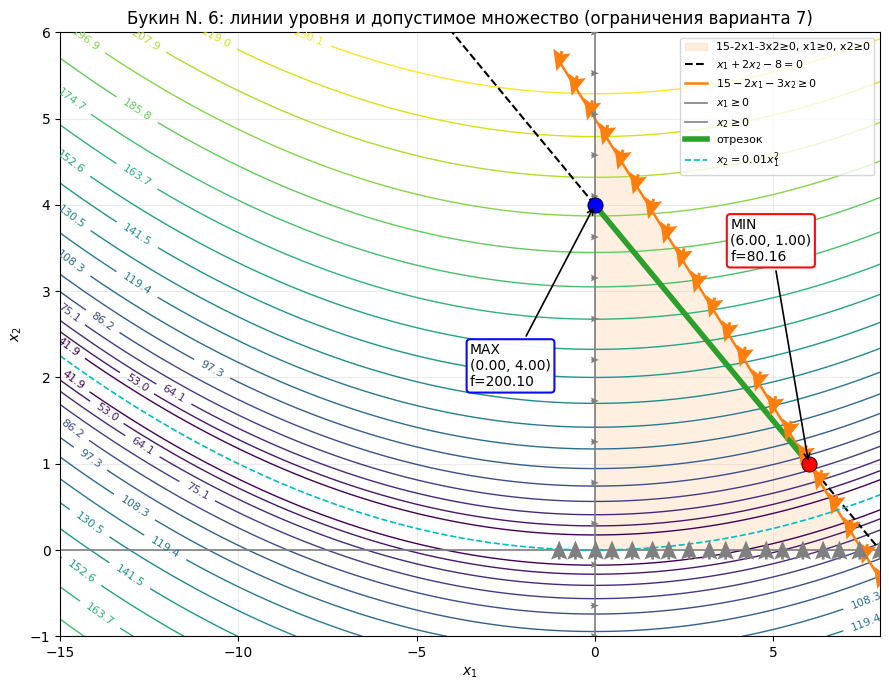

In [ ]:
# Букин N.6: 2D уровни + ограничения + отрезок

import numpy as np
import matplotlib.pyplot as plt


def bukin_6(x1, x2):
    """Букин N.6."""
    return 100.0 * np.sqrt(np.abs(x2 - 0.01 * np.square(x1))) + 0.01 * np.abs(x1 + 10.0)


def g1(x1, x2):
    return 15 - 2 * x1 - 3 * x2


def h2(x1, x2):
    return x1 + 2 * x2 - 8


def g3(x1, x2):
    return x1


def g4(x1, x2):
    return x2


x1 = np.linspace(-15.0, 8.0, 600)
x2 = np.linspace(-1.0, 6.0, 600)
X1, X2 = np.meshgrid(x1, x2)
Z = bukin_6(X1, X2)

fig, ax = plt.subplots(figsize=(9, 7))

levels = np.linspace(np.percentile(Z, 5), np.percentile(Z, 95), 18)
cs = ax.contour(X1, X2, Z, levels=levels, linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Область неравенств: x1>=0, x2>=0, 15-2x1-3x2>=0
x1_fill = np.linspace(0, 8, 600)
x2_g1 = (15 - 2 * x1_fill) / 3
x2_g1_clip = np.clip(x2_g1, 0, 6)
ax.fill_between(
    x1_fill,
    0,
    x2_g1_clip,
    where=x2_g1 > 0,
    color="tab:orange",
    alpha=0.12,
    label="15-2x1-3x2≥0, x1≥0, x2≥0",
    zorder=0,
)

# Границы
x2_line = np.linspace(-1, 6, 400)
ax.plot(8 - 2 * x2_line, x2_line, "k--", lw=1.5, label=r"$x_1+2x_2-8=0$")

x1_line = np.linspace(-1, 8, 400)
ax.plot(x1_line, (15 - 2 * x1_line) / 3, color="tab:orange", lw=1.8, label=r"$15-2x_1-3x_2\geq 0$")

ax.axvline(0, color="gray", lw=1.2, label=r"$x_1\geq 0$")
ax.axhline(0, color="gray", lw=1.2, label=r"$x_2\geq 0$")


def add_boundary_arrows(
    ax,
    xs,
    ys,
    dx,
    dy,
    *,
    n=18,
    length=0.25,
    color="red",
    width=0.004,
    zorder=6,
):
    """Стрелочки вдоль границы."""
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    if xs.size < 2:
        return

    idx = np.linspace(0, xs.size - 1, n).astype(int)
    xq = xs[idx]
    yq = ys[idx]

    norm = float((dx * dx + dy * dy) ** 0.5)
    if norm == 0:
        return
    ux, uy = dx / norm, dy / norm

    U = np.full_like(xq, ux * length, dtype=float)
    V = np.full_like(yq, uy * length, dtype=float)

    ax.quiver(
        xq,
        yq,
        U,
        V,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
        color=color,
        zorder=zorder,
        pivot="mid",
        headwidth=6,
        headlength=7,
        headaxislength=6,
    )


# Стрелки внутрь области
y_g1 = (15 - 2 * x1_line) / 3
mask = (y_g1 >= -1) & (y_g1 <= 6)
add_boundary_arrows(ax, x1_line[mask], y_g1[mask], dx=-2, dy=-3, n=22, length=0.28, color="tab:orange", width=0.0045)

_yv = np.linspace(-1, 6, 60)
_xv = np.zeros_like(_yv)
add_boundary_arrows(ax, _xv, _yv, dx=1, dy=0, n=16, length=0.22, color="gray", width=0.004)

_xh = np.linspace(-1, 8, 80)
_yh = np.zeros_like(_xh)
add_boundary_arrows(ax, _xh, _yh, dx=0, dy=1, n=18, length=0.22, color="gray", width=0.004)

# Допустимый отрезок (x2 in [1, 4])
x2_seg = np.linspace(1.0, 4.0, 300)
x1_seg = 8.0 - 2.0 * x2_seg
ax.plot(x1_seg, x2_seg, color="tab:green", lw=4, label="отрезок")

# MIN / MAX на отрезке
x2_den = np.linspace(1.0, 4.0, 4000)
x1_den = 8.0 - 2.0 * x2_den
f_den = bukin_6(x1_den, x2_den)
i_min = int(np.argmin(f_den))
i_max = int(np.argmax(f_den))
xmin_s, ymin_s = float(x1_den[i_min]), float(x2_den[i_min])
xmax_s, ymax_s = float(x1_den[i_max]), float(x2_den[i_max])
fmin_s, fmax_s = float(f_den[i_min]), float(f_den[i_max])

# Кривая канавки
xv = np.linspace(-15.0, 8.0, 500)
ax.plot(xv, 0.01 * xv**2, "c--", lw=1.2, label=r"$x_2 = 0.01x_1^2$")

ax.scatter([xmin_s], [ymin_s], s=120, color="red", zorder=7, edgecolors="black", linewidths=0.6)
ax.scatter([xmax_s], [ymax_s], s=120, color="blue", zorder=7, edgecolors="black", linewidths=0.6)

ax.annotate(
    f"MIN\n({xmin_s:.2f}, {ymin_s:.2f})\nf={fmin_s:.2f}",
    xy=(xmin_s, ymin_s),
    xytext=(xmin_s - 2.2, ymin_s + 2.35),
    arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", linewidth=1.5, alpha=0.96),
    zorder=10,
)
ax.annotate(
    f"MAX\n({xmax_s:.2f}, {ymax_s:.2f})\nf={fmax_s:.2f}",
    xy=(xmax_s, ymax_s),
    xytext=(xmax_s - 3.5, ymax_s - 2.1),
    arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="blue", linewidth=1.5, alpha=0.96),
    zorder=10,
)

ax.set_title("Букин N. 6: линии уровня и допустимое множество (ограничения варианта 7)")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim(-15, 8)
ax.set_ylim(-1, 6)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


### Букин N.6 — 3D

Сейчас построим 3D‑график функции Букина и отметим точки на отрезке. Также добавим траектории, если они уже посчитаны.


In [ ]:
# Функция Букина N. 6
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio


def bukin_6(x1, x2):
    """Букин N.6."""
    return 100.0 * np.sqrt(np.abs(x2 - 0.01 * np.square(x1))) + 0.01 * np.abs(x1 + 10.0)


x1 = np.linspace(-15.0, 14.0, 261)
x2 = np.linspace(-3.0, 5.0, 220)
X1, X2 = np.meshgrid(x1, x2, indexing="xy")
Z = bukin_6(X1, X2)

z_lo, z_hi = float(np.nanmin(Z)), float(np.nanmax(Z))

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Z,
        colorscale="Viridis",
        name="f(x1,x2)",
        showscale=False,
        showlegend=False,
    )
)

# h2 = 0 (линии)
_x2w = np.linspace(-3.0, 5.0, 200)
_zw = np.linspace(z_lo, z_hi, 49)
_px, _py, _pz = [], [], []
for _x2 in _x2w[::2]:
    _x1 = 8.0 - 2.0 * _x2
    _px += [_x1, _x1, None]
    _py += [_x2, _x2, None]
    _pz += [z_lo, z_hi, None]
for _zv in _zw[::2]:
    _x1l = 8.0 - 2.0 * _x2w
    _px.extend(_x1l.tolist() + [None])
    _py.extend(_x2w.tolist() + [None])
    _pz.extend([_zv] * len(_x2w) + [None])
fig.add_trace(
    go.Scatter3d(
        x=_px,
        y=_py,
        z=_pz,
        mode="lines",
        line=dict(color="rgb(255, 130, 40)", width=4),
        name="h2 = 0",
        hoverinfo="skip",
    )
)

# MIN / MAX на отрезке (x2 in [1,4])
_x2d = np.linspace(1.0, 4.0, 4000)
_x1d = 8.0 - 2.0 * _x2d
_fd = bukin_6(_x1d, _x2d)
_i_min_seg = int(np.argmin(_fd))
_i_max_seg = int(np.argmax(_fd))
x1_min_seg = float(_x1d[_i_min_seg])
x2_min_seg = float(_x2d[_i_min_seg])
z_min_seg = float(_fd[_i_min_seg])
x1_max_seg = float(_x1d[_i_max_seg])
x2_max_seg = float(_x2d[_i_max_seg])
z_max_seg = float(_fd[_i_max_seg])

fig.add_trace(
    go.Scatter3d(
        x=[x1_max_seg],
        y=[x2_max_seg],
        z=[z_max_seg],
        mode="markers+text",
        marker=dict(
            size=12,
            color="#377eb8",
            symbol="circle",
            line=dict(width=2, color="black"),
        ),
        text=[f"MAX<br>({x1_max_seg:.2f}, {x2_max_seg:.2f})<br>f={z_max_seg:.2f}"],
        textposition="top center",
        name="MAX (отрезок)",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[x1_min_seg],
        y=[x2_min_seg],
        z=[z_min_seg],
        mode="markers+text",
        marker=dict(
            size=12,
            color="#e41a1c",
            symbol="circle",
            line=dict(width=2, color="black"),
        ),
        text=[f"MIN<br>({x1_min_seg:.2f}, {x2_min_seg:.2f})<br>f={z_min_seg:.2f}"],
        textposition="bottom center",
        name="MIN (отрезок)",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[-10.0],
        y=[1.0],
        z=[0.0],
        mode="markers+text",
        marker=dict(
            size=11,
            color="#984ea3",
            symbol="diamond",
            line=dict(width=1.5, color="black"),
        ),
        text=["глоб.<br>мин."],
        textposition="middle left",
        name="(-10, 1), f=0",
    )
)

# Траектории (если посчитаны выше)
try:
    _bk_runs_a = bukin_all_runs_armijo
    _bk_runs_w = bukin_all_runs_wolfe
except NameError:
    _bk_runs_a, _bk_runs_w = [], []

_traj_specs_bk = (
    (
        _bk_runs_a,
        "Армихо",
        {1: "red", 2: "deepskyblue"},
        {1: "darkred", 2: "blue"},
        5,
        4,
    ),
    (
        _bk_runs_w,
        "Вульф",
        {1: "#e377c2", 2: "#ff7f0e"},
        {1: "#7b3294", 2: "#a65628"},
        4,
        3,
    ),
)
for _all_r_bk, _tag_bk, _pal_f_bk, _pal_P_bk, _lw_f_bk, _lw_P_bk in _traj_specs_bk:
    for _run_bk in _all_r_bk:
        _hist_bk = _run_bk["hist"]
        _xs_bk = np.array(_hist_bk["x"])
        _x1s_bk, _x2s_bk = _xs_bk[:, 0], _xs_bk[:, 1]
        _zf_bk = np.array(_hist_bk["f"])
        _zP_bk = np.array(_hist_bk["P"])
        _n_bk = len(_x1s_bk)
        _eid_bk = _run_bk["exp"]["id"]
        _ekey_bk = (
            int(_eid_bk)
            if isinstance(_eid_bk, (int, str)) and str(_eid_bk).isdigit()
            else _eid_bk
        )
        _cf_bk = _pal_f_bk.get(_ekey_bk, "black")
        _cP_bk = _pal_P_bk.get(_ekey_bk, "gray")
        fig.add_trace(
            go.Scatter3d(
                x=_x1s_bk,
                y=_x2s_bk,
                z=_zf_bk,
                mode="lines+markers",
                marker=dict(size=3, color=_cf_bk),
                line=dict(width=_lw_f_bk, color=_cf_bk),
                name=f"эксп. {_eid_bk}: f(x), {_tag_bk} (n={_n_bk})",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=_x1s_bk,
                y=_x2s_bk,
                z=_zP_bk,
                mode="lines+markers",
                marker=dict(size=3, color=_cP_bk),
                line=dict(width=_lw_P_bk, color=_cP_bk),
                name=f"эксп. {_eid_bk}: P(x,r), {_tag_bk} (n={_n_bk})",
            )
        )

fig.update_layout(
    title="Функция Букина N. 6",
    width=1000,
    height=720,
    margin=dict(r=200),
    legend=dict(
        x=1.02,
        y=0.98,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.92)",
        bordercolor="lightgray",
        borderwidth=1,
        font=dict(size=11),
    ),
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="f(x) и P(x,r)",
        camera=dict(eye=dict(x=1.35, y=-1.65, z=0.55)),
    ),
)
pio.renderers.default = "browser"
fig.show()